

**Deep Learning**
1. Foward Neural Networks

In [26]:
#importing all the necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [27]:
data = pd.read_csv('/content/predict_energy_consumption.xls')
data.head()

,temperature,humidity,wind_speed,solar_irradiance,energy_consumption
0,24.363503,31.107976,5.234114,705.432695,307.398145
1,38.767858,52.514057,4.939576,817.013257,412.444548
2,33.299849,72.376750,18.125092,325.421109,392.072418
3,29.966462,63.933493,4.990924,662.386690,119.254957
4,18.900466,68.393669,5.438995,614.571385,117.162261


In [28]:
#Feature & Target Selection
data.columns

Index(['temperature', 'humidity', 'wind_speed', 'solar_irradiance',
       'energy_consumption'],
      dtype='object')

In [29]:
X = data[['temperature', 'humidity', 'wind_speed', 'solar_irradiance']]
y = data['energy_consumption']

In [30]:
#Splitting the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=42
)

In [31]:
#Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [32]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [34]:
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=2)

Epoch 1/50
20/20 - 3s - 133ms/step - loss: 90419.5781 - mae: 271.8161 - val_loss: 83734.3594 - val_mae: 259.0850
Epoch 2/50
20/20 - 0s - 11ms/step - loss: 89923.7422 - mae: 270.9066 - val_loss: 83180.9531 - val_mae: 258.0193
Epoch 3/50
20/20 - 0s - 15ms/step - loss: 89223.6875 - mae: 269.6103 - val_loss: 82336.0781 - val_mae: 256.3860
Epoch 4/50
20/20 - 0s - 13ms/step - loss: 88161.8281 - mae: 267.6309 - val_loss: 81055.7969 - val_mae: 253.8887
Epoch 5/50
20/20 - 0s - 10ms/step - loss: 86546.4219 - mae: 264.6208 - val_loss: 79176.1250 - val_mae: 250.1723
Epoch 6/50
20/20 - 0s - 13ms/step - loss: 84252.1016 - mae: 260.1401 - val_loss: 76478.9375 - val_mae: 244.7383
Epoch 7/50
20/20 - 1s - 28ms/step - loss: 81015.7734 - mae: 253.8907 - val_loss: 72883.0781 - val_mae: 237.2872
Epoch 8/50
20/20 - 0s - 16ms/step - loss: 76784.5625 - mae: 245.3578 - val_loss: 68256.3594 - val_mae: 227.3111
Epoch 9/50
20/20 - 0s - 5ms/step - loss: 71463.3359 - mae: 234.1913 - val_loss: 62682.8516 - val_mae: 2

In [35]:
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=2)
print(f'Test Loss: {test_loss}, Test MAE:{test_mae}')

7/7 - 1s - 88ms/step - loss: 18357.6797 - mae: 116.6006
Test Loss: 18357.6796875, Test MAE:116.60059356689453


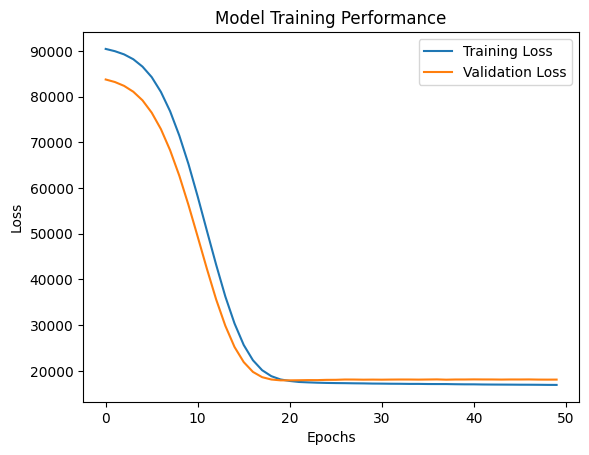

In [36]:
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Training Performance')
plt.legend()
plt.show()

In [37]:
predictions = model.predict(X_test)
predictions

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


array([[280.8619 ],
       [252.7916 ],
       [252.14453],
       [212.81516],
       [334.454  ],
       [302.3679 ],
       [303.5887 ],
       [286.59195],
       [299.83044],
       [279.57425],
       [235.58615],
       [261.4133 ],
       [273.39066],
       [225.78372],
       [294.8489 ],
       [324.74716],
       [261.9929 ],
       [314.73563],
       [305.14944],
       [253.71683],
       [268.17874],
       [278.51712],
       [269.81546],
       [264.6694 ],
       [249.70493],
       [247.34814],
       [246.10252],
       [306.92935],
       [325.1418 ],
       [265.9141 ],
       [235.93898],
       [316.44016],
       [284.66916],
       [263.56656],
       [318.7391 ],
       [295.85086],
       [218.5285 ],
       [257.67313],
       [281.3909 ],
       [236.36261],
       [249.35315],
       [259.50577],
       [253.42145],
       [264.8459 ],
       [273.0071 ],
       [251.44656],
       [261.40582],
       [254.69328],
       [303.1263 ],
       [288.59756],


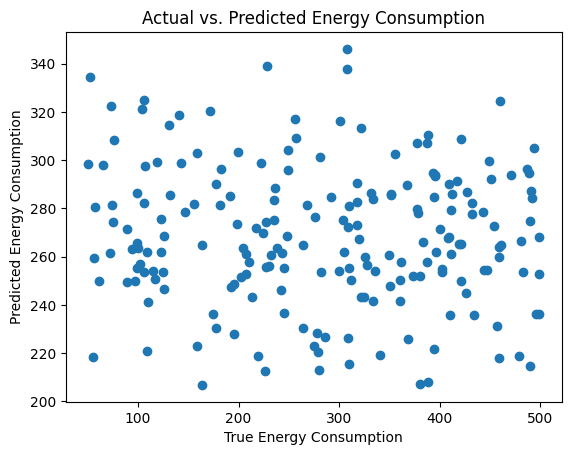

In [38]:
plt.scatter(y_test, predictions)
plt.xlabel('True Energy Consumption')
plt.ylabel('Predicted Energy Consumption')
plt.title('Actual vs. Predicted Energy Consumption')
plt.show()